In [191]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../data/gold/quartier_metrics.csv")
# or
df = pd.read_parquet("../data/gold/quartier_metrics.parquet")

<Axes: xlabel='quartier_name'>

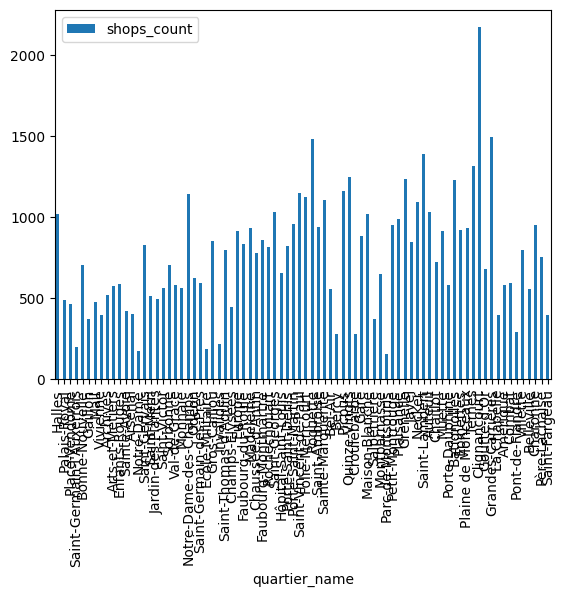

In [192]:
df.plot.bar(x="quartier_name", y="shops_count")

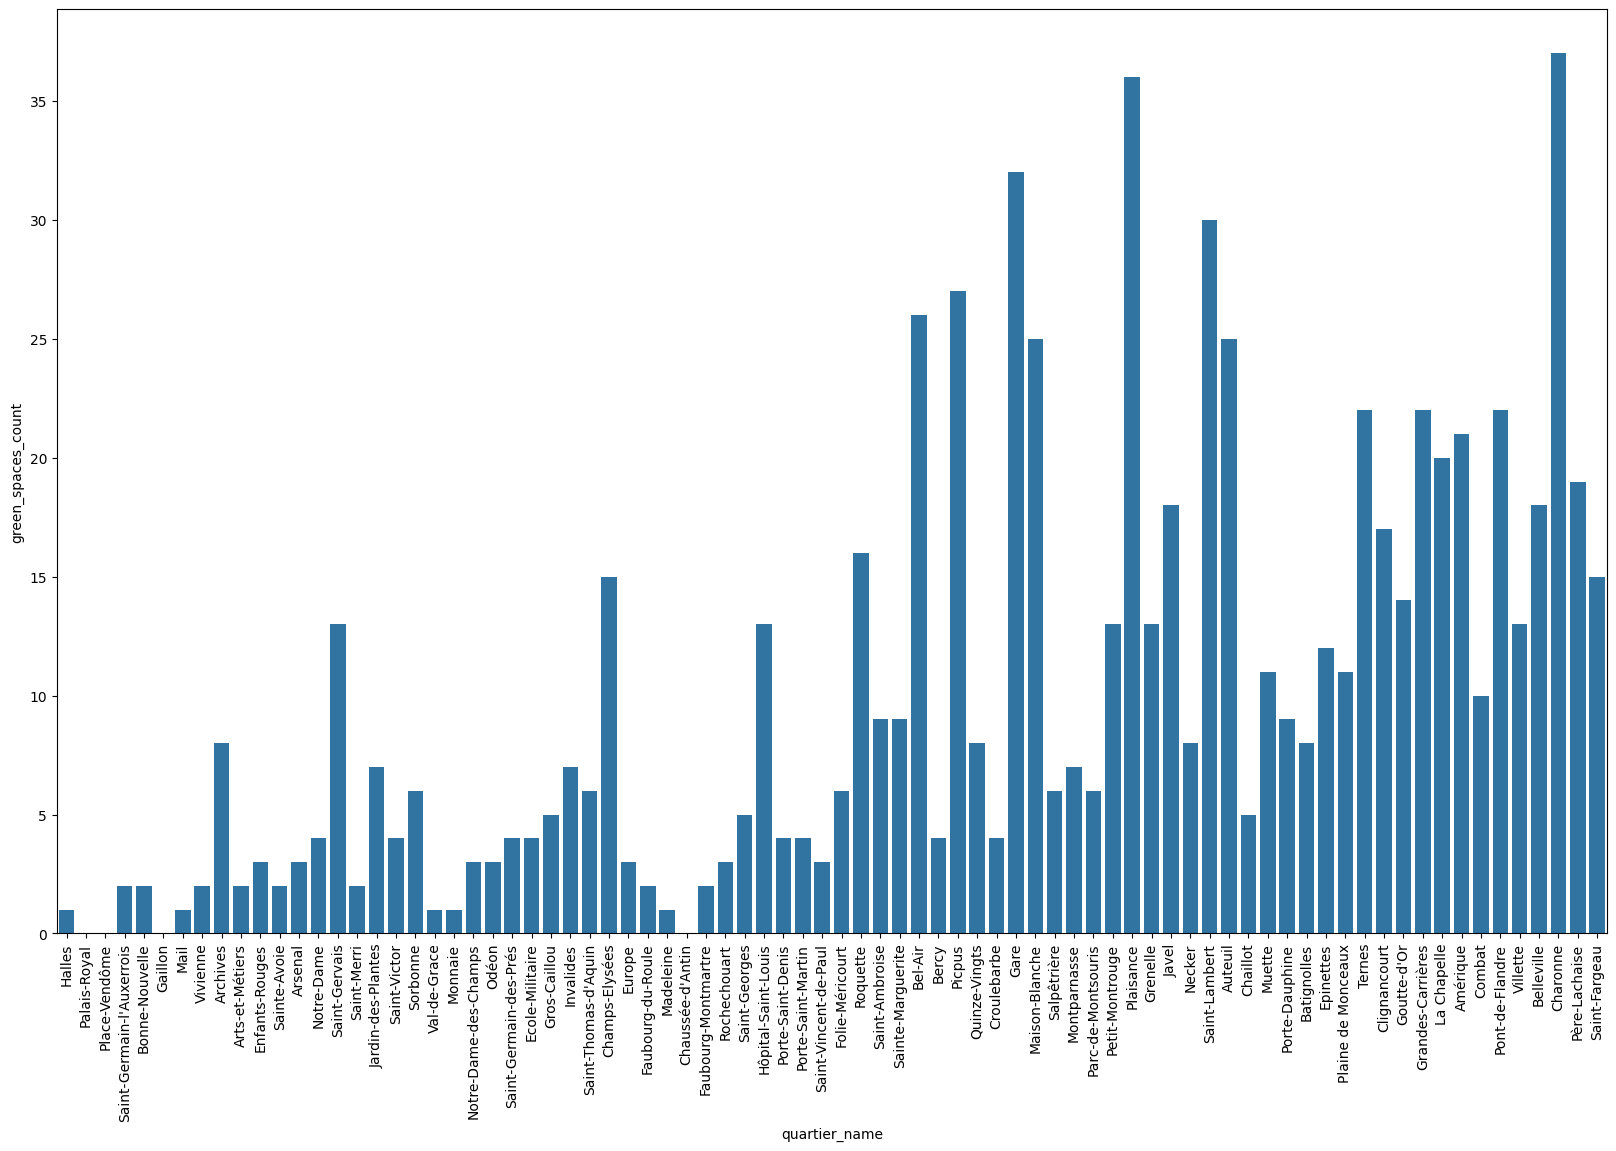

In [193]:
plt.figure(figsize=(20, 12))

sns.barplot(data=df, x="quartier_name", y="green_spaces_count")
plt.xticks(rotation=90)
plt.show()

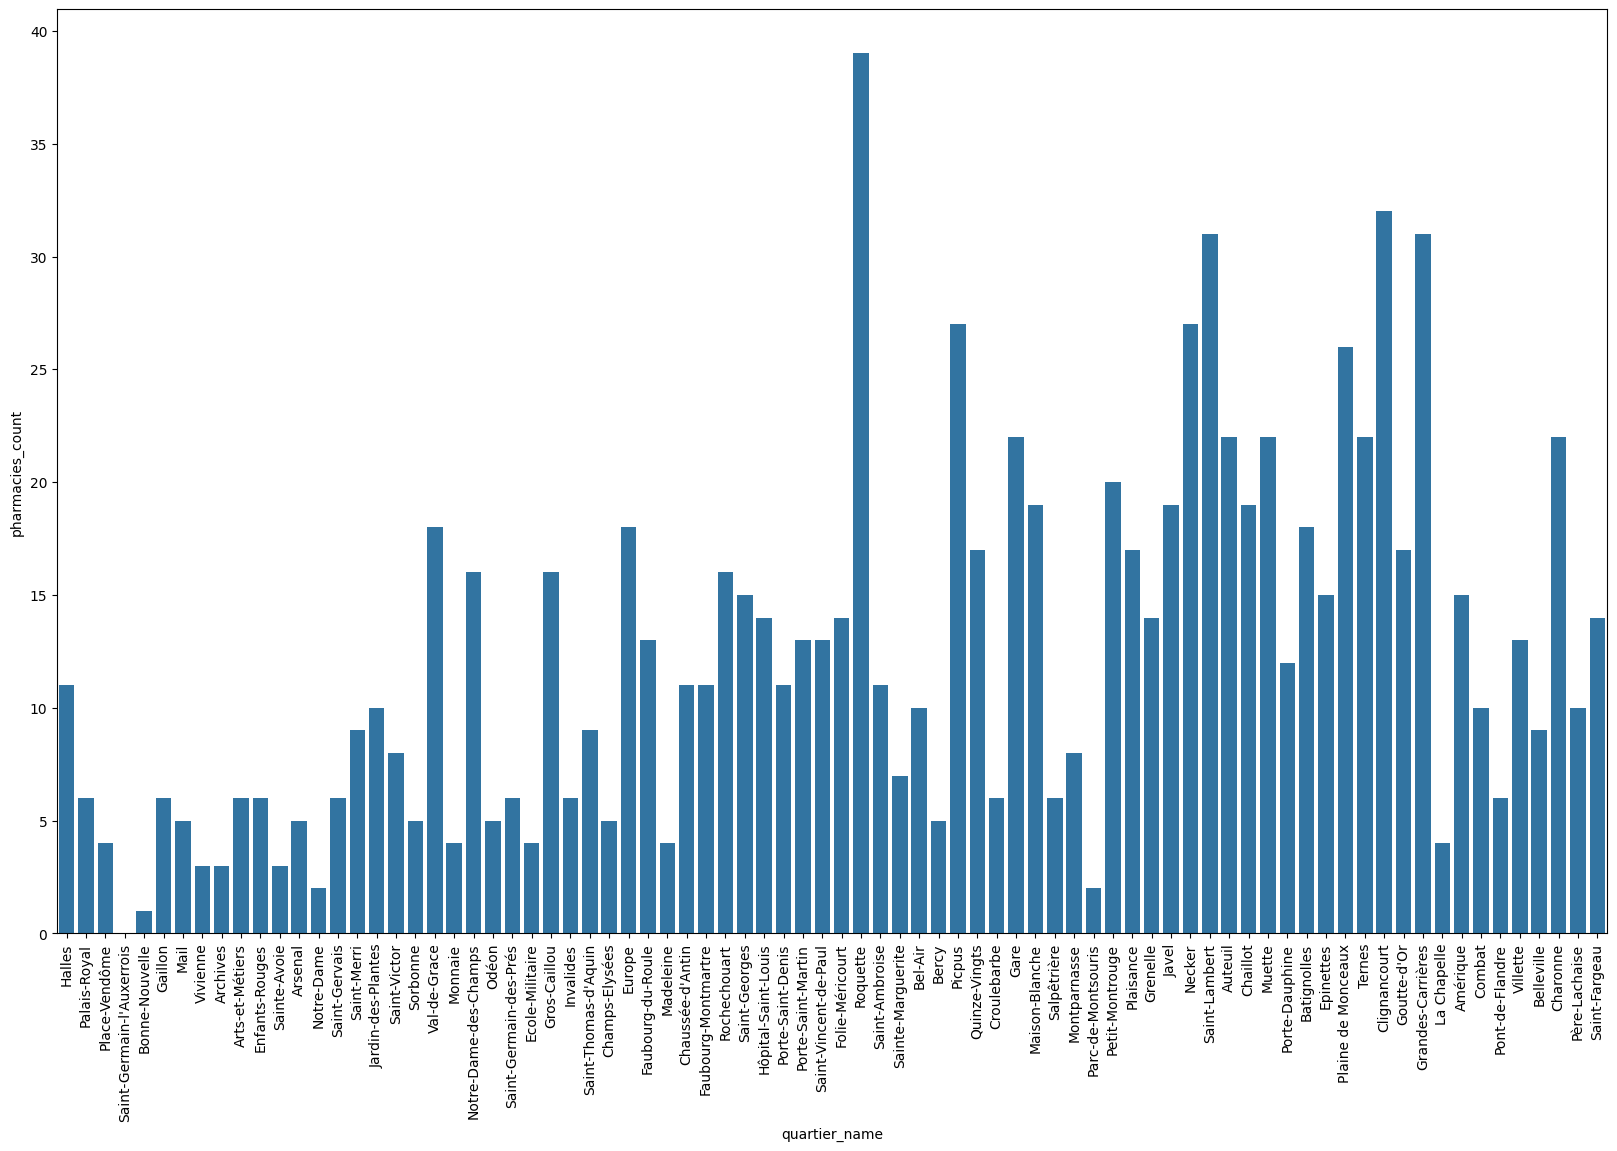

In [194]:
plt.figure(figsize=(20, 12))

sns.barplot(data=df, x="quartier_name", y="pharmacies_count")
plt.xticks(rotation=90)
plt.show()

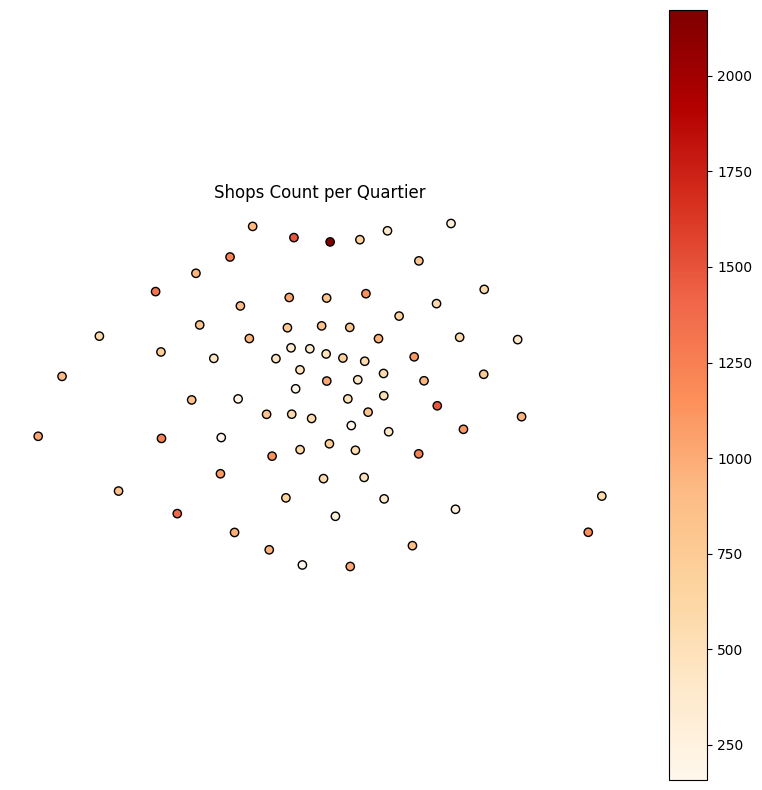

In [195]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Load quartier polygons (GeoDataFrame)
quartiers = gpd.read_parquet("../data/quartiers/quartier_paris.parquet")

# Load metrics
metrics = pd.read_csv("../data/gold/quartier_metrics.csv")

# Merge on quartier_code (adjust column names if needed)
#gdf = quartiers.merge(metrics, left_on="c_qu", right_on="quartier_code")
quartiers["c_qu"] = quartiers["c_qu"].astype(str)
metrics["quartier_code"] = metrics["quartier_code"].astype(str)
gdf = quartiers.merge(metrics, left_on="c_qu", right_on="quartier_code")

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(column="shops_count", ax=ax, legend=True, cmap="OrRd", edgecolor="black")
ax.set_title("Shops Count per Quartier")
ax.axis("off")
plt.show()

In [196]:
print(quartiers.columns)

Index(['n_sq_qu', 'c_qu', 'c_quinsee', 'l_qu', 'c_ar', 'n_sq_ar', 'perimetre',
       'surface', 'geom_x_y', 'geom', 'st_area_shape', 'st_perimeter_shape'],
      dtype='object')


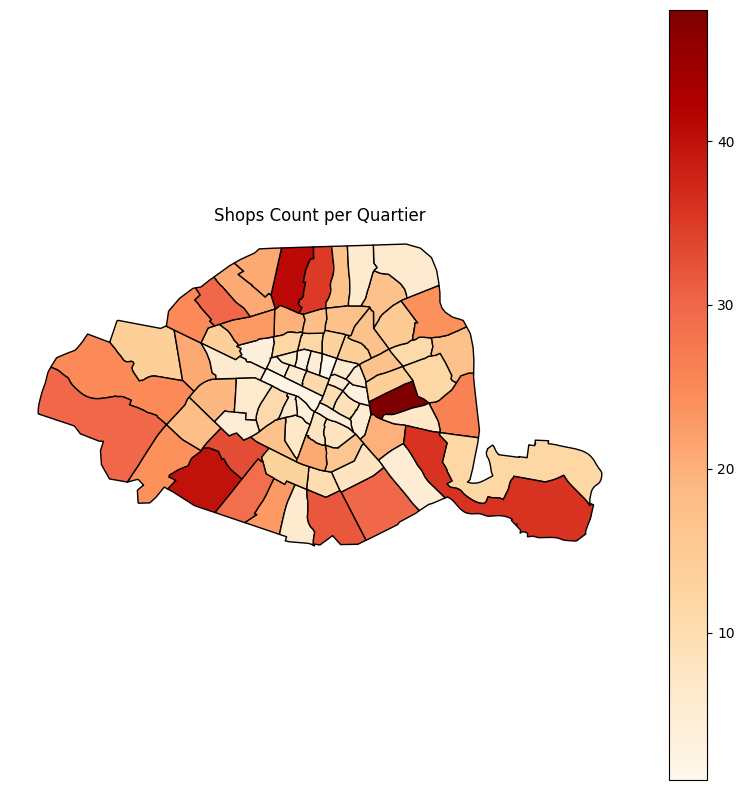

In [197]:
# ... (after your merge) ...

# 1. Convert to GeoDataFrame (in case the merge turned it into a standard DataFrame)
gdf = gpd.GeoDataFrame(gdf, geometry="geom")

# 2. Ensure it's using the correct Coordinate Reference System (usually WGS84 for Paris Open Data)
if gdf.crs is None:
    gdf.set_crs(epsg=4326, inplace=True)

# 3. Plot using the "geom" column
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(column="health_services", ax=ax, legend=True, cmap="OrRd", edgecolor="black")
ax.set_title("Shops Count per Quartier")
ax.axis("off")
plt.show()

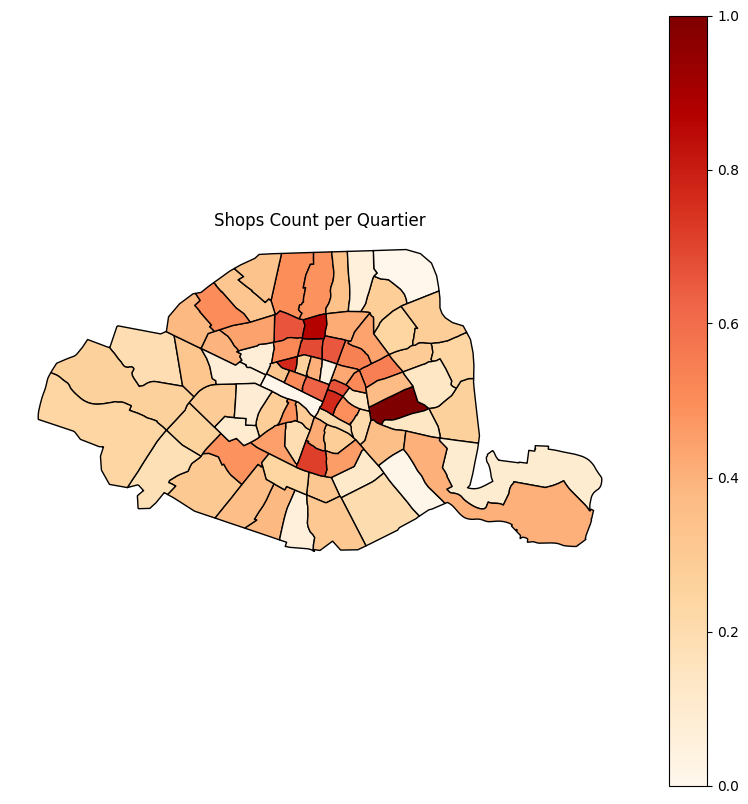

In [198]:
# Load quartier polygons (GeoDataFrame)
quartiers2 = gpd.read_parquet("../data/quartiers/quartier_paris.parquet")

# Load metrics
metrics2 = pd.read_csv("../data/gold/quartier_scores.csv")

# Merge on quartier_code (adjust column names if needed)
#gdf2 = quartiers2.merge(metrics2, left_on="c_qu", right_on="quartier_code")
quartiers2["c_qu"] = quartiers2["c_qu"].astype(str)
metrics2["quartier_code"] = metrics2["quartier_code"].astype(str)
gdf2 = quartiers2.merge(metrics2, left_on="c_qu", right_on="quartier_code")

# ... (after your merge) ...

# 1. Convert to GeoDataFrame (in case the merge turned it into a standard DataFrame)
gdf2 = gpd.GeoDataFrame(gdf2, geometry="geom")

# 2. Ensure it's using the correct Coordinate Reference System (usually WGS84 for Paris Open Data)
if gdf2.crs is None:
    gdf2.set_crs(epsg=4326, inplace=True)

# 3. Plot using the "geom" column
fig, ax = plt.subplots(figsize=(10, 10))
gdf2.plot(column="score_health", ax=ax, legend=True, cmap="OrRd", edgecolor="black")
ax.set_title("Shops Count per Quartier")
ax.axis("off")
plt.show()

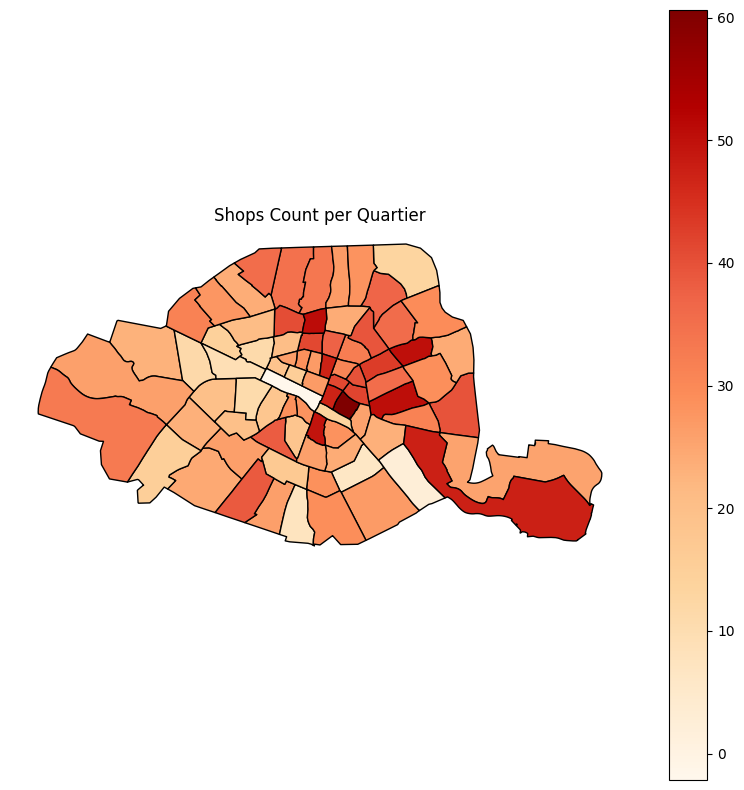

In [199]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf2.plot(column="score_junior", ax=ax, legend=True, cmap="OrRd", edgecolor="black")
ax.set_title("Shops Count per Quartier")
ax.axis("off")
plt.show()

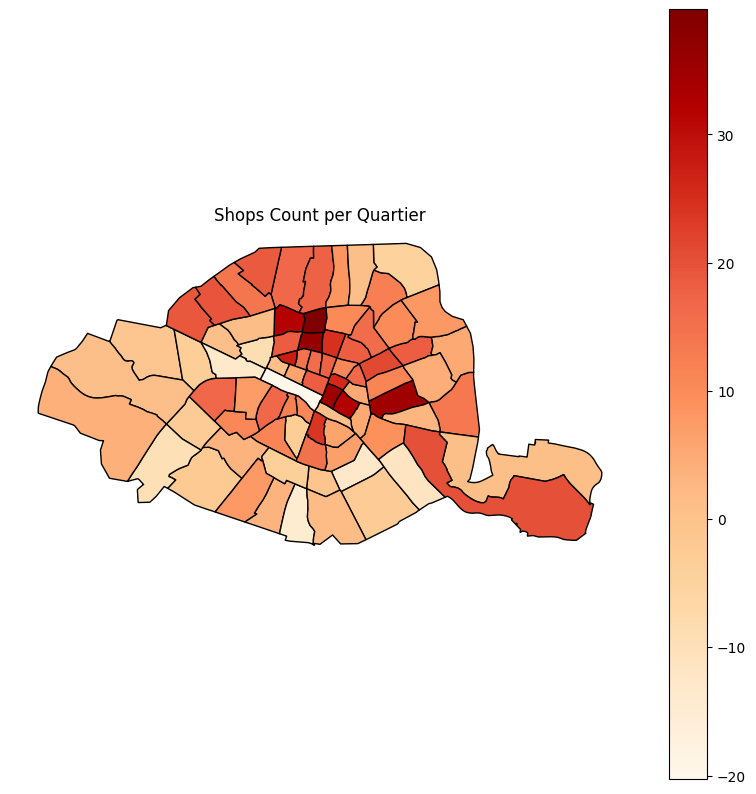

In [200]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf2.plot(column="score_senior", ax=ax, legend=True, cmap="OrRd", edgecolor="black")
ax.set_title("Shops Count per Quartier")
ax.axis("off")
plt.show()

In [16]:
path = "../data/quartiers/adresse_paris.parquet"
df = pd.read_parquet(path)

print("shape:", df.shape)
print("columns:", list(df.columns))
print(df.head(10))

shape: (153073, 18)
columns: ['geom_x_y', 'geom', 'n_sq_ad', 'n_voie', 'c_suf1', 'c_suf2', 'c_suf3', 'c_ar', 'a_nvoie', 'b_angle', 'b_offstdf', 'b_affstdf', 'b_hors75', 'l_nvoie', 'l_adr', 'n_sq_ar', 'n_sq_vo', 'objectid']
                                            geom_x_y  \
0  b'\x01\x01\x00\x00\x00`=\xd9[\xa30\x03@\x8a\xc...   
1  b'\x01\x01\x00\x00\x00(\xa9~\x1e\x99\xe9\x02@&...   
2  b'\x01\x01\x00\x00\x00E\x98\xf5\xc0^w\x02@\x8f...   
3  b'\x01\x01\x00\x00\x00\t\x07\xac\xf5\xb91\x02@...   
4  b'\x01\x01\x00\x00\x00{\xb1W\x08=y\x02@-\x00\x...   
5  b'\x01\x01\x00\x00\x00\x8e\xd7{\xbb8\xd9\x02@\...   
6  b'\x01\x01\x00\x00\x00\xe2\x873\x1d\xab\x13\x0...   
7  b'\x01\x01\x00\x00\x00={\xc3\xe7r\x94\x02@uy\x...   
8  b'\x01\x01\x00\x00\x00\xb8\xe9\x0cE\xf8\x07\x0...   
9  b'\x01\x01\x00\x00\x00\xcb\xf0\xdc\xdeg\xcf\x0...   

                                                geom    n_sq_ad  n_voie  \
0  b'\x01\x01\x00\x00\x00`=\xd9[\xa30\x03@\x8a\xc...  750064575    12.0   
1  b'\x01\